In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, make_scorer, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
data_path = 'data/'
df_lists = []

customers_df = pd.read_csv(data_path + 'olist_customers_dataset.csv')
geolocation_df = pd.read_csv(data_path + 'olist_geolocation_dataset.csv')
order_items_df = pd.read_csv(data_path + 'olist_order_items_dataset.csv')
order_payments_df = pd.read_csv(data_path + 'olist_order_payments_dataset.csv')
order_reviews_df = pd.read_csv(data_path + 'olist_order_reviews_dataset.csv')
orders_df = pd.read_csv(data_path + 'olist_orders_dataset.csv')
products_df = pd.read_csv(data_path + 'olist_products_dataset.csv')
sellers_df = pd.read_csv(data_path + 'olist_sellers_dataset.csv')
category_translation_df = pd.read_csv(data_path + 'product_category_name_translation.csv')

df_lists.append(customers_df)
df_lists.append(geolocation_df)
df_lists.append(order_items_df)
df_lists.append(order_payments_df)
df_lists.append(order_reviews_df)
df_lists.append(orders_df)
df_lists.append(products_df)
df_lists.append(sellers_df)
df_lists.append(category_translation_df)

df_names = ['customers', 'geolocation', 'order_items', 'order_payments', 'order_reviews', 'orders', 'products', 'sellers', 'category_translation']

### **Manejo de valores Nulos**

#### order_reviews_df

In [3]:
print("=== Análisis de nulos en order_reviews_df ===")
print("Valores nulos:")
print(order_reviews_df.isnull().sum())
print("\nPorcentaje de nulos:")
print((order_reviews_df.isnull().sum() / len(order_reviews_df)) * 100)

=== Análisis de nulos en order_reviews_df ===
Valores nulos:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Porcentaje de nulos:
review_id                   0.000000
order_id                    0.000000
review_score                0.000000
review_comment_title       88.341530
review_comment_message     58.702532
review_creation_date        0.000000
review_answer_timestamp     0.000000
dtype: float64


Los nulos en las columnas `review_comment_title` (**88.34%**) y `review_comment_message` (**58.70%**) son esperados, ya que los comentarios son opcionales. Imputar con texto genérico podría sesgar análisis de texto, y eliminar filas eliminaría la mayoría de los datos.

Se creará una columna binaria `has_comment` para indicar si hay comentario en `review_comment_message`

In [4]:
order_reviews_df['has_comment'] = order_reviews_df['review_comment_message'].notnull().astype(int)

#### orders_df

In [5]:
print("\n=== Análisis de nulos en orders_df ===")
print("Valores nulos:")
print(orders_df.isnull().sum())
print("\nPorcentaje de nulos:")
print((orders_df.isnull().sum() / len(orders_df)) * 100)
print("\nDistribución de order_status para order_delivered_customer_date nulo:")
print(orders_df[orders_df['order_delivered_customer_date'].isnull()]['order_status'].value_counts())


=== Análisis de nulos en orders_df ===
Valores nulos:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Porcentaje de nulos:
order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.160899
order_delivered_carrier_date     1.793023
order_delivered_customer_date    2.981668
order_estimated_delivery_date    0.000000
dtype: float64

Distribución de order_status para order_delivered_customer_date nulo:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count

Los nulos en `order_approved_at`(**0.16%**), `order_delivered_carrier_date` (**1.79%**), y `order_delivered_customer_date` (**2.98%**) están relacionados con el estado del pedido. Según los datos de `order_status` para `order_delivered_customer_date` nulo, la mayoría corresponde a pedidos no entregados (**shipped**, **canceled**, **unavailable**, etc.), con solo 8 casos en delivered. Los nulos en `order_approved_at` y `order_delivered_carrier_date` también reflejan pedidos en etapas incompletas.

Se creará una columna binaria `delivered` para indicar si el pedido fue entregado

In [6]:
orders_df['delivered'] = orders_df['order_delivered_customer_date'].notnull().astype(int)

#### products_df

In [7]:
print("\n=== Análisis de nulos en products_df ===")
print("Valores nulos:")
print(products_df.isnull().sum())
print("\nPorcentaje de nulos:")
print((products_df.isnull().sum() / len(products_df)) * 100)


=== Análisis de nulos en products_df ===
Valores nulos:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
dtype: int64

Porcentaje de nulos:
product_id                    0.000000
product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.003035
product_length_cm             0.003035
product_height_cm             0.003035
product_width_cm              0.003035
dtype: float64


Los **610** nulos (**1.85%**) en `product_category_name`, `product_name_lenght`, `product_description_lenght`, y `product_photos_qty` corresponden a las mismas filas. Mientras que los nulos en dimensiones es únicamente **1**. 
Se imputarán:
- **Desconocido** para ``categorías``
- **0** para ``fotos``
- **medianas** para ``numéricos``

In [8]:
products_df['product_category_name']= products_df['product_category_name'].fillna('Desconocido')
products_df['product_photos_qty'] = products_df['product_photos_qty'].fillna(0)
for col in ['product_name_lenght', 'product_description_lenght', 'product_weight_g', 
            'product_length_cm', 'product_height_cm', 'product_width_cm']:
    products_df[col] = products_df[col].fillna(products_df[col].median())

In [9]:
print("\n=== Resumen final de nulos ===")
for df, name in zip(df_lists, df_names):
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print(f"\n{name}:")
        print(null_counts[null_counts > 0])
    else:
        print(f"\n{name}: No hay nulos.")


=== Resumen final de nulos ===

customers: No hay nulos.

geolocation: No hay nulos.

order_items: No hay nulos.

order_payments: No hay nulos.

order_reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64

orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

products: No hay nulos.

sellers: No hay nulos.

category_translation: No hay nulos.


Los valores nulos que quedan ya están respaldados con las nuevas columnas agregadas.

### **Armar Data Frame**

In [10]:
# Paso 1: orders_df como base
merged_df = orders_df.copy()

# Paso 2: Unir con customers_df
merged_df = pd.merge(merged_df, customers_df, on='customer_id', how='left')
print("\nDespués de unir con customers_df:", merged_df.shape)
print("\nNulos:")
print(merged_df.isnull().sum())

# Paso 3: Unir con order_reviews_df
# Nota: Puede haber múltiples reseñas por pedido, tomaremos la primera
order_reviews_unique = order_reviews_df.sort_values('review_creation_date').groupby('order_id').first()[
    ['review_score', 'has_comment']
].reset_index()
merged_df = pd.merge(merged_df, order_reviews_unique, on='order_id', how='left')
print("Después de unir con order_reviews_df:", merged_df.shape)
print("\nNulos:")
print(merged_df.isnull().sum())

# Paso 4: Unir con order_items_df
# Agregar ítems por pedido (promedio de precio, flete, y conteo de ítems)
order_items_agg = order_items_df.groupby('order_id').agg({
    'price': 'mean',  # Promedio del precio de los ítems
    'freight_value': 'mean',  # Promedio del valor del flete
    'order_item_id': 'count'  # Número de ítems por pedido
}).reset_index().rename(columns={
    'price': 'avg_item_price',
    'freight_value': 'avg_freight_value',
    'order_item_id': 'num_items'
})
merged_df = pd.merge(merged_df, order_items_agg, on='order_id', how='left')
print("Después de unir con order_items_df (agregado):", merged_df.shape)
print("\nNulos:")
print(merged_df.isnull().sum())

# Paso 5: Unir con products_df
# Primero, obtener product_id principal por pedido (el primero en order_items_df)
order_items_product = order_items_df[['order_id', 'product_id']].drop_duplicates()
order_items_product = order_items_product.groupby('order_id').first().reset_index()
merged_df = pd.merge(merged_df, order_items_product, on='order_id', how='left')
merged_df = pd.merge(merged_df, products_df, on='product_id', how='left')
print("Después de unir con products_df:", merged_df.shape)
print("\nNulos:")
print(merged_df.isnull().sum())

# Paso 6: Unir con category_translation_df
merged_df = pd.merge(merged_df, category_translation_df, 
                     on='product_category_name', how='left')
print("Después de unir con category_translation_df:", merged_df.shape)
print("\nNulos:")
print(merged_df.isnull().sum())

# Paso 7: Unir con order_payments_df
# Agregar pagos por pedido (suma del valor pagado)
order_payments_agg = order_payments_df.groupby('order_id').agg({
    'payment_value': 'sum'  # Suma total de pagos
}).reset_index().rename(columns={'payment_value': 'total_payment'})
merged_df = pd.merge(merged_df, order_payments_agg, on='order_id', how='left')
print("Después de unir con order_payments_df (agregado):", merged_df.shape)
print("\nNulos:")
print(merged_df.isnull().sum())

# Paso 8: Unir con sellers_df
# Usar seller_id del primer ítem por pedido
order_items_seller = order_items_df[['order_id', 'seller_id']].drop_duplicates()
order_items_seller = order_items_seller.groupby('order_id').first().reset_index()
merged_df = pd.merge(merged_df, order_items_seller, on='order_id', how='left')
merged_df = pd.merge(merged_df, sellers_df, on='seller_id', how='left')
print("Después de unir con sellers_df:", merged_df.shape)
print("\nNulos:")
print(merged_df.isnull().sum())


Después de unir con customers_df: (99441, 13)

Nulos:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
delivered                           0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
dtype: int64
Después de unir con order_reviews_df: (99441, 15)

Nulos:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
delivered                           0
customer_unique_id                  0


In [11]:
print("\nColumnas del DataFrame combinado:")
print(merged_df.columns.tolist())
print("\nPrimeras 5 filas:")
print(merged_df.head())
print("\nResumen de nulos en el DataFrame combinado:")
print(merged_df.isnull().sum())


Columnas del DataFrame combinado:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivered', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score', 'has_comment', 'avg_item_price', 'avg_freight_value', 'num_items', 'product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'total_payment', 'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

Primeras 5 filas:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41


=== Correlaciones para merged_df ===

Matriz de correlación:
                            delivered  customer_zip_code_prefix  review_score  \
delivered                    1.000000                  0.011771      0.297684   
customer_zip_code_prefix     0.011771                  1.000000     -0.016474   
review_score                 0.297684                 -0.016474      1.000000   
has_comment                 -0.085224                  0.000977     -0.259207   
avg_item_price              -0.023959                  0.042402     -0.012437   
avg_freight_value           -0.017776                  0.227864     -0.038331   
num_items                    0.005927                 -0.002680     -0.115457   
product_name_lenght          0.019060                  0.014569     -0.009764   
product_description_lenght  -0.006320                  0.023647      0.011540   
product_photos_qty           0.005765                  0.018510      0.016163   
product_weight_g            -0.008699          

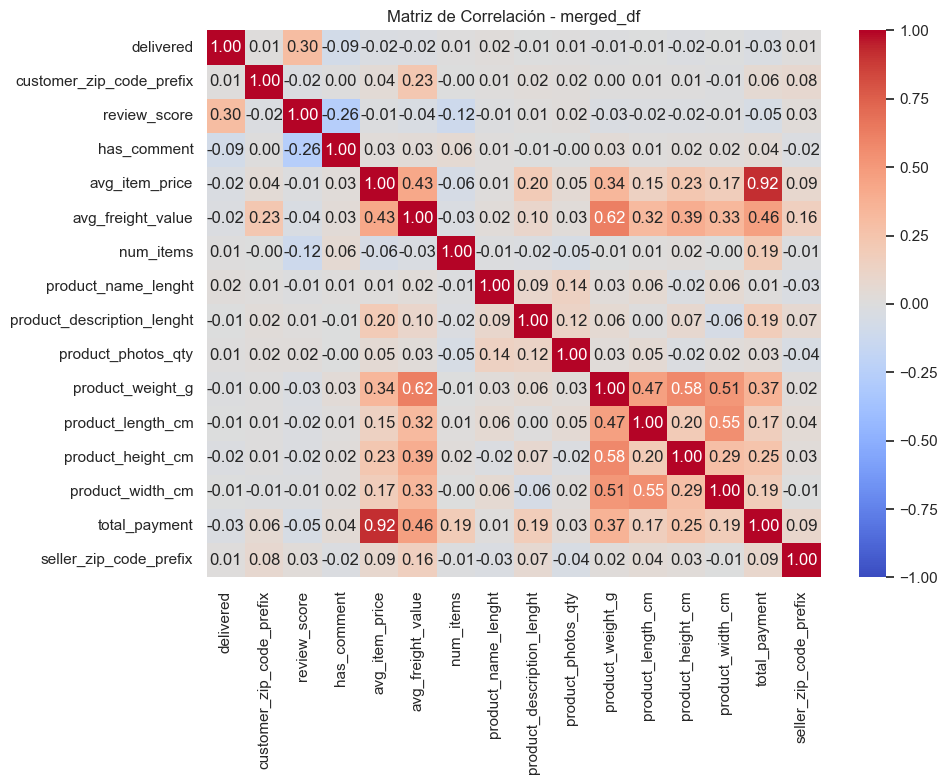

In [12]:
print("\n=== Correlaciones para merged_df ===\n")

# Seleccionar columnas numéricas
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) < 2:
    print("No hay suficientes columnas numéricas en merged_df para calcular correlaciones.")
else:
    # Calcular matriz de correlación
    corr_matrix = merged_df[numeric_cols].corr()
    
    # Imprimir matriz de correlación
    print("Matriz de correlación:")
    print(corr_matrix)
    
    # Visualizar heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f')
    plt.title('Matriz de Correlación - merged_df')
    plt.tight_layout()
    plt.show()


#### Correlaciones con ``review_score``:
- ``delivered`` (**0.2975**): Correlación positiva moderada. Los pedidos entregados (**delivered=1**) tienden a tener mejores puntuaciones, lo cual es esperado.
- ``has_comment`` (**-0.2593**): Correlación negativa moderada. Los pedidos con comentarios (has_comment=1) tienden a tener puntuaciones más bajas, posiblemente porque los clientes insatisfechos son más propensos a dejar comentarios.
- ``num_items`` (**-0.1156**): Correlación negativa débil. Pedidos con más ítems tienden a tener puntuaciones ligeramente más bajas, quizás por mayor complejidad logística.
- ``total_payment`` (**-0.0491**), avg_freight_value (**-0.0381**), product_weight_g (**-0.0305**): Correlaciones negativas muy débiles. Mayor gasto, costo de envío o peso del producto tienen un impacto mínimo en la puntuación.
- ``avg_item_price`` (**-0.0121**), product_name_lenght (**-0.0096**), product_photos_qty (**0.0162**): Correlaciones cercanas a cero, sugiriendo poca influencia directa en review_score.

**Conclusión**: Las variables relacionadas con la entrega (``delivered``) y los comentarios (``has_comment``) son las más relevantes para review_score. Las variables de precio, peso y dimensiones tienen correlaciones débiles. Esto sugiere que lo que más influye en las calificaciones del usuario es respecto al servicio al cliente y el estado de orden que del producto como tal.

#### Correlaciones entre Otras Variables:
- ``avg_item_price`` y ``total_payment`` (**0.9211**): Correlación muy fuerte, ya que ``total_payment`` incluye los precios de los ítems. Esto sugiere redundancia; podríamos usar solo una de las dos en los modelos.
- ``avg_freight_value`` y ``product_weight_g`` (**0.6173**), ``product_length_cm`` (**0.3181**), ``product_height_cm`` (**0.3944**), ``product_width_cm`` (**0.3319**): Correlaciones moderadas a fuertes. El costo de envío está relacionado con el peso y las dimensiones del producto, lo cual es lógico.
``avg_item_price`` y ``avg_freight_value`` (**0.4258**): Correlación moderada. Productos más caros tienden a tener costos de envío más altos.
``product_weight_g`` con ``product_length_cm`` (**0.4671**), ``product_height_cm`` (**0.5799**), ``product_width_cm`` (**0.5128**): Correlaciones moderadas, ya que el peso está relacionado con las dimensiones.

**Conclusión**: Hay multicolinealidad entre variables como ``avg_item_price``, ``total_payment``, ``avg_freight_value``, y las dimensiones del producto. Esto puede afectar modelos de regresión, por lo que podríamos eliminar variables redundantes o usar técnicas como PCA.

#### Variables con Baja Correlación:
- ``customer_zip_code_prefix`` y ``seller_zip_code_prefix``: Correlaciones débiles con casi todas las variables, incluyendo review_score. Los códigos postales pueden no ser útiles como variables numéricas directas; podríamos convertirlos en categorías (por ejemplo, estado).
- ``product_name_lenght``, ``product_description_lenght``, ``product_photos_qty``: Correlaciones débiles con review_score y otras variables, sugiriendo que estas características del producto tienen poca influencia en la satisfacción.

##### **Conclusión**
Como hay una correlación bastante débil, se propone crear más variables a partir de las que tuvieron mejores resultados:
- ``estimated_delivery_days``: Días laborables entre ``order_approved_at`` y ``order_estimated_delivery_date`` (usando np.busday_count).

- ``actual_delivery_days``: Días laborables entre ``order_approved_at`` y ``order_delivered_customer_date``.

- ``delivery_time_delta``: Diferencia entre ``actual_delivery_days`` y ``estimated_delivery_days``.

- ``is_late``: **1** si ``delivery_time_delta`` **> 0**, **0** si no.

- ``total_order_value``: (``avg_item_price`` * ``num_items``) + (``avg_freight_value`` * ``num_items``).

- ``freight_ratio``: ``avg_freight_value`` / ``avg_item_price`` (**0** si ``avg_item_price`` es **0**).

- ``purchase_day_of_week``: Día de la semana de ``order_purchase_timestamp`` (**0=Lunes, 6=Domingo**).

In [13]:
print("\nNulos antes de manejo:")
print(merged_df.isnull().sum())


Nulos antes de manejo:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
delivered                           0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
review_score                      768
has_comment                       768
avg_item_price                    775
avg_freight_value                 775
num_items                         775
product_id                        775
product_category_name             775
product_name_lenght               775
product_description_lenght        775
product_photos_qty                775
product_weight_g                  775
product_length_cm                 775
product_height_cm         

### **Volver a manejar valores nulos**

In [14]:
print("=== Manejo de Nulos en merged_df ===")

print("\nNulos antes de manejo:")
print(merged_df.isnull().sum())

numeric_cols = [
    'review_score', 'avg_item_price', 'avg_freight_value', 'num_items',
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'total_payment', 'seller_zip_code_prefix'
]
for col in numeric_cols:
    merged_df[col] =  merged_df[col].fillna(merged_df[col].median())

merged_df['product_category_name'] = merged_df['product_category_name'].fillna('Desconocido')
merged_df['product_category_name_english'] = merged_df['product_category_name_english'].fillna('Unknown')
merged_df['seller_city'] = merged_df['seller_city'].fillna(merged_df['seller_city'].mode()[0])
merged_df['seller_state'] = merged_df['seller_state'].fillna(merged_df['seller_state'].mode()[0])

print("\nNulos después de manejo:")
print(merged_df.isnull().sum())

=== Manejo de Nulos en merged_df ===

Nulos antes de manejo:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
delivered                           0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
review_score                      768
has_comment                       768
avg_item_price                    775
avg_freight_value                 775
num_items                         775
product_id                        775
product_category_name             775
product_name_lenght               775
product_description_lenght        775
product_photos_qty                775
product_weight_g                  775
product_length_cm          

### **Creación de features adicionales**
- ``estimated_delivery_days``: Días laborables entre ``order_approved_at`` y ``order_estimated_delivery_date`` (usando np.busday_count).

- ``actual_delivery_days``: Días laborables entre ``order_approved_at`` y ``order_delivered_customer_date``.

- ``delivery_time_delta``: Diferencia entre ``actual_delivery_days`` y ``estimated_delivery_days``.

- ``is_late``: **1** si ``delivery_time_delta`` **> 0**, **0** si no.

- ``total_order_value``: (``avg_item_price`` * ``num_items``) + (``avg_freight_value`` * ``num_items``).

- ``freight_ratio``: ``avg_freight_value`` / ``avg_item_price`` (**0** si ``avg_item_price`` es **0**).

- ``purchase_day_of_week``: Día de la semana de ``order_purchase_timestamp`` (**0=Lunes, 6=Domingo**).

In [15]:
# Convertir columnas de fechas a datetime
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    merged_df[col] = pd.to_datetime(merged_df[col])

# Feature 1: Working Days Estimated Delivery Time
# Días laborables entre order_approved_at y order_estimated_delivery_date
merged_df['estimated_delivery_days'] = merged_df.apply(
    lambda x: np.busday_count(
        x['order_approved_at'].date() if pd.notnull(x['order_approved_at']) else x['order_purchase_timestamp'].date(),
        x['order_estimated_delivery_date'].date()
    ),
    axis=1
).clip(lower=0)

# Feature 2: Working Days Actual Delivery Time
# Días laborables entre order_approved_at y order_delivered_customer_date
merged_df['actual_delivery_days'] = merged_df.apply(
    lambda x: np.busday_count(
        x['order_approved_at'].date() if pd.notnull(x['order_approved_at']) else x['order_purchase_timestamp'].date(),
        x['order_delivered_customer_date'].date()
    ) if pd.notnull(x['order_delivered_customer_date']) else np.nan,
    axis=1
).clip(lower=0)

# Feature 3: Working Days Delivery Time Delta
# Diferencia entre actual y estimado (negativo = temprano, positivo = tarde)
merged_df['delivery_time_delta'] = merged_df['actual_delivery_days'] - merged_df['estimated_delivery_days']

# Feature 4: Is Late
# Binario: 1 si delivery_time_delta > 0, 0 si no
merged_df['is_late'] = (merged_df['delivery_time_delta'] > 0).astype(int)

# Feature 5: Average Product Value
# Ya está en avg_item_price

# Feature 6: Total Order Value
# Suma de avg_item_price * num_items + avg_freight_value * num_items
merged_df['total_order_value'] = (
    merged_df['avg_item_price'] * merged_df['num_items'] + 
    merged_df['avg_freight_value'] * merged_df['num_items']
)

# Feature 7: Order Freight Ratio
# avg_freight_value / avg_item_price (evitar división por cero)
merged_df['freight_ratio'] = np.where(
    merged_df['avg_item_price'] > 0,
    merged_df['avg_freight_value'] / merged_df['avg_item_price'],
    0
)

# Feature 8: Purchase Day of Week
# Día de la semana de order_purchase_timestamp (0=Lunes, 6=Domingo)
merged_df['purchase_day_of_week'] = merged_df['order_purchase_timestamp'].dt.dayofweek

# Imputar nulos en features derivadas de fechas
merged_df['actual_delivery_days'].fillna(merged_df['actual_delivery_days'].median(), inplace=True)
merged_df['delivery_time_delta'].fillna(merged_df['delivery_time_delta'].median(), inplace=True)
merged_df['is_late'].fillna(0, inplace=True)  # Asumir no tarde si no hay datos

# Verificación
print("\nPrimeras 5 filas con nuevas features:")
print(merged_df[[
    'review_score', 'estimated_delivery_days', 'actual_delivery_days', 
    'delivery_time_delta', 'is_late', 'avg_item_price', 'total_order_value', 
    'freight_ratio', 'purchase_day_of_week'
]].head())



Primeras 5 filas con nuevas features:
   review_score  estimated_delivery_days  actual_delivery_days  \
0           4.0                       12                   6.0   
1           4.0                       12                   8.0   
2           5.0                       19                   7.0   
3           5.0                       19                  10.0   
4           5.0                        9                   3.0   

   delivery_time_delta  is_late  avg_item_price  total_order_value  \
0                 -6.0        0           29.99              38.71   
1                 -4.0        0          118.70             141.46   
2                -12.0        0          159.90             179.12   
3                 -9.0        0           45.00              72.20   
4                 -6.0        0           19.90              28.62   

   freight_ratio  purchase_day_of_week  
0       0.290764                     0  
1       0.191744                     1  
2       0.120200    

C:\Users\juans\AppData\Local\Temp\ipykernel_9236\3214937175.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['actual_delivery_days'].fillna(merged_df['actual_delivery_days'].median(), inplace=True)
C:\Users\juans\AppData\Local\Temp\ipykernel_9236\3214937175.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are


=== Correlaciones con Nuevas Features ===

Correlaciones con review_score:
review_score                  1.000000
delivered                     0.287151
seller_zip_code_prefix        0.029700
product_photos_qty            0.024932
product_description_lenght    0.015274
avg_item_price               -0.008194
product_width_cm             -0.008618
purchase_day_of_week         -0.008666
product_name_lenght          -0.013845
product_length_cm            -0.014283
freight_ratio                -0.016275
customer_zip_code_prefix     -0.016767
product_height_cm            -0.018646
product_weight_g             -0.024400
avg_freight_value            -0.034100
total_order_value            -0.041018
total_payment                -0.048005
estimated_delivery_days      -0.051446
num_items                    -0.107418
delivery_time_delta          -0.241915
has_comment                  -0.259207
actual_delivery_days         -0.295780
is_late                      -0.346821
Name: review_score, dtype: 

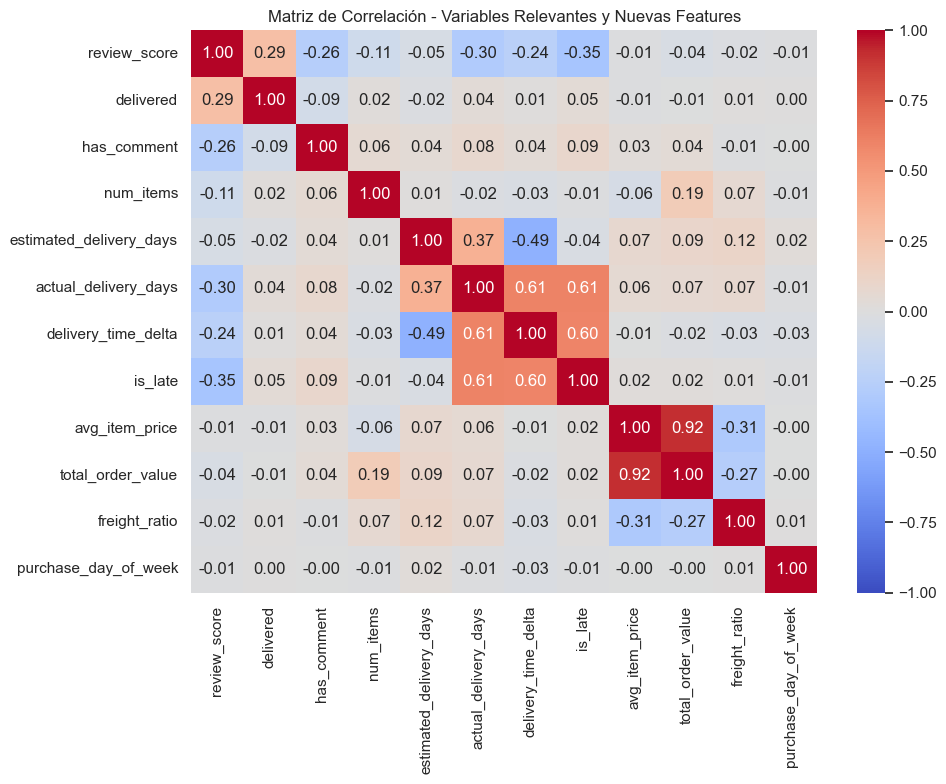

In [16]:
print("\n=== Correlaciones con Nuevas Features ===")

# Seleccionar columnas numéricas
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns

# Calcular matriz de correlación
corr_matrix = merged_df[numeric_cols].corr()

# Imprimir correlaciones con review_score
print("\nCorrelaciones con review_score:")
print(corr_matrix['review_score'].sort_values(ascending=False))

# Visualizar heatmap de correlaciones relevantes
relevant_cols = [
    'review_score', 'delivered', 'has_comment', 'num_items', 
    'estimated_delivery_days', 'actual_delivery_days', 'delivery_time_delta', 
    'is_late', 'avg_item_price', 'total_order_value', 'freight_ratio', 
    'purchase_day_of_week'
]
corr_matrix_relevant = merged_df[relevant_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_relevant, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f')
plt.title('Matriz de Correlación - Variables Relevantes y Nuevas Features')
plt.tight_layout()
plt.show()


=== Correlaciones para merged_df ===

Matriz de correlación:
                            delivered  customer_zip_code_prefix  review_score  \
delivered                    1.000000                  0.011771      0.287151   
customer_zip_code_prefix     0.011771                  1.000000     -0.016767   
review_score                 0.287151                 -0.016767      1.000000   
has_comment                 -0.085224                  0.000977     -0.259207   
avg_item_price              -0.009705                  0.042388     -0.008194   
avg_freight_value           -0.004514                  0.227086     -0.034100   
num_items                    0.016857                 -0.002497     -0.107418   
product_name_lenght          0.002410                  0.014302     -0.013845   
product_description_lenght   0.007671                  0.023739      0.015274   
product_photos_qty           0.035888                  0.018856      0.024932   
product_weight_g             0.009112          

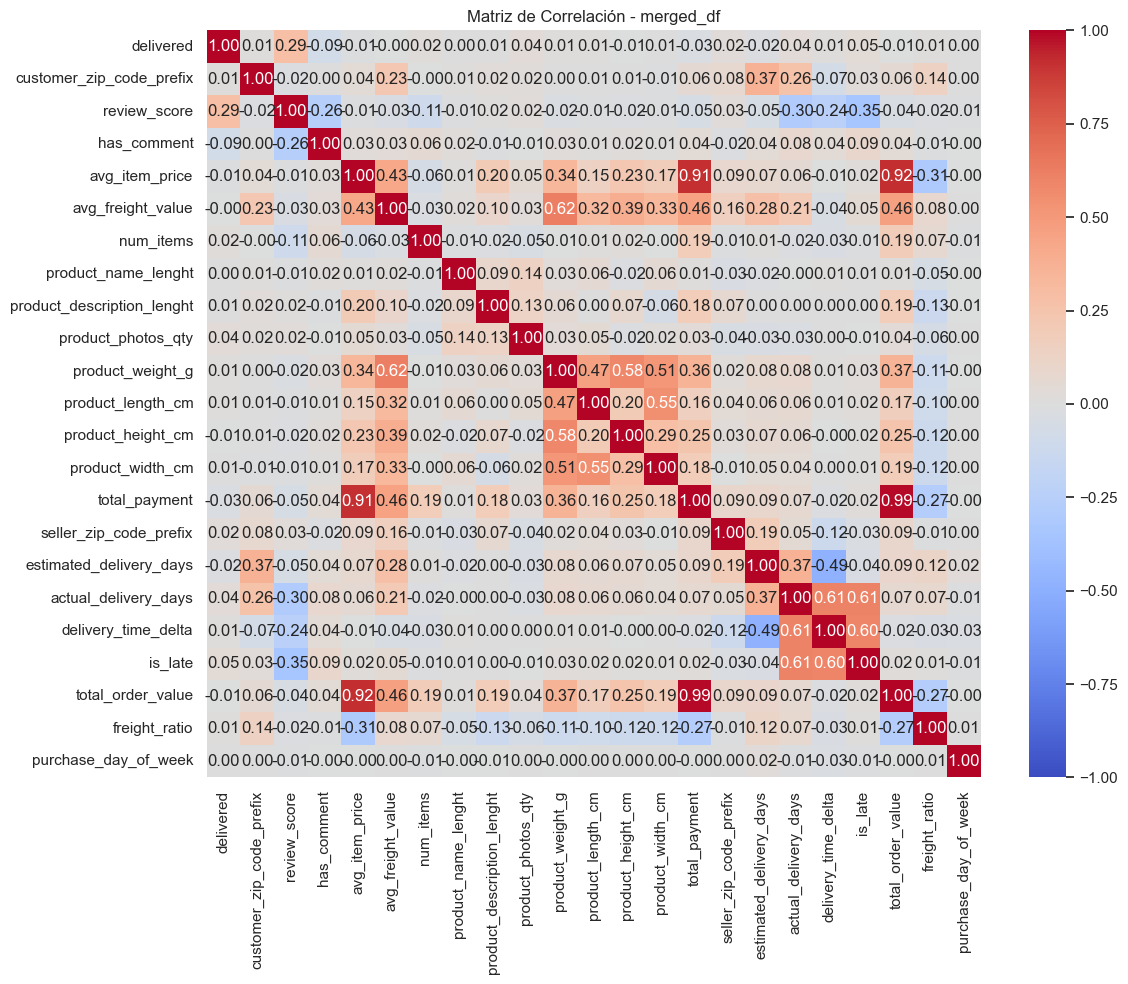

In [19]:
print("\n=== Correlaciones para merged_df ===\n")

# Seleccionar columnas numéricas
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) < 2:
    print("No hay suficientes columnas numéricas en merged_df para calcular correlaciones.")
else:
    # Calcular matriz de correlación
    corr_matrix = merged_df[numeric_cols].corr()
    
    # Imprimir matriz de correlación
    print("Matriz de correlación:")
    print(corr_matrix)
    
    # Visualizar heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f')
    plt.title('Matriz de Correlación - merged_df')
    plt.tight_layout()
    plt.show()


### **Analisis del DF luego de crear features**

- Se decidio eliminar la variable total_payment debido principalmente a dos razones:
1. Esta variable representa el valor total pagado por un pedido, pero es directamente derivable de otras tres variables ya presentes en el conjunto de datos: avg_item_price, avg_freight_value y num_items. En concreto, la lógica detrás de total_payment es una suma de los montos pagados por los productos más los costos promedio de envío, multiplicados por la cantidad de artículos. Al mantener las variables base, no se pierde información relevante, ya que total_payment puede ser fácilmente reconstruida en caso de ser necesaria.
2. Al realizar el analisis de correlacion se descubrio que esta variable introduce multicolinealidad en el dataset, especificamente con las variables avg_item_price y total_order_value, pudiendo asi dificultar la identificación de relaciones reales entre variables.

In [20]:
# Eliminar la columna 'total_payment'
merged_df.drop(columns=['total_payment'], inplace=True)

# Verificación
print("'total_payment' eliminada. Columnas actuales:")
print(merged_df.columns.tolist())


'total_payment' eliminada. Columnas actuales:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivered', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score', 'has_comment', 'avg_item_price', 'avg_freight_value', 'num_items', 'product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'estimated_delivery_days', 'actual_delivery_days', 'delivery_time_delta', 'is_late', 'total_order_value', 'freight_ratio', 'purchase_day_of_week']



=== Correlaciones para merged_df ===

Matriz de correlación:
                            delivered  customer_zip_code_prefix  review_score  \
delivered                    1.000000                  0.011771      0.287151   
customer_zip_code_prefix     0.011771                  1.000000     -0.016767   
review_score                 0.287151                 -0.016767      1.000000   
has_comment                 -0.085224                  0.000977     -0.259207   
avg_item_price              -0.009705                  0.042388     -0.008194   
avg_freight_value           -0.004514                  0.227086     -0.034100   
num_items                    0.016857                 -0.002497     -0.107418   
product_name_lenght          0.002410                  0.014302     -0.013845   
product_description_lenght   0.007671                  0.023739      0.015274   
product_photos_qty           0.035888                  0.018856      0.024932   
product_weight_g             0.009112          

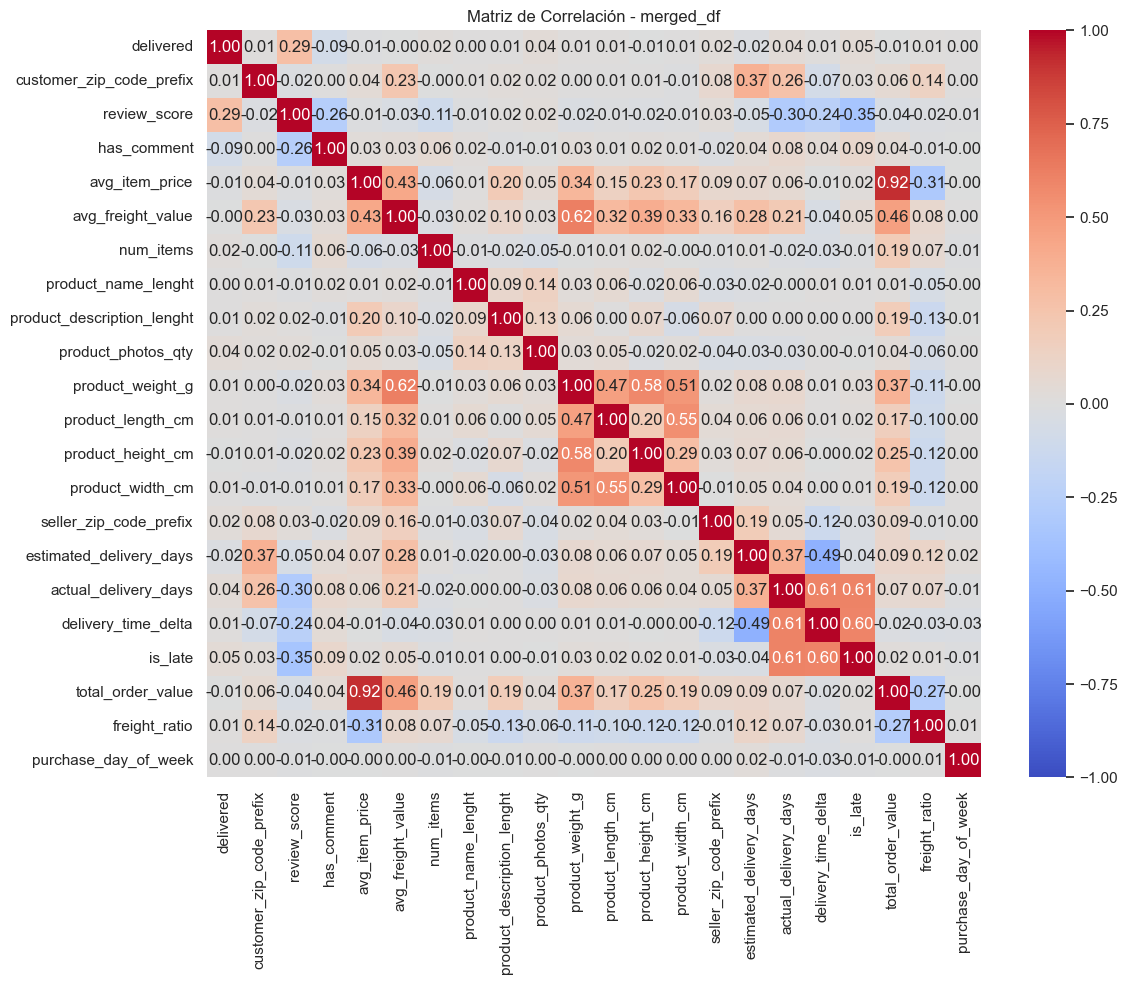

In [21]:
print("\n=== Correlaciones para merged_df ===\n")

# Seleccionar columnas numéricas
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) < 2:
    print("No hay suficientes columnas numéricas en merged_df para calcular correlaciones.")
else:
    # Calcular matriz de correlación
    corr_matrix = merged_df[numeric_cols].corr()
    
    # Imprimir matriz de correlación
    print("Matriz de correlación:")
    print(corr_matrix)
    
    # Visualizar heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f')
    plt.title('Matriz de Correlación - merged_df')
    plt.tight_layout()
    plt.show()


In [ ]:
output_path = 'merged_dataset.csv'
merged_df.to_csv(output_path, index=False)

# Verificación
print(f"\nDataFrame guardado en: {output_path}")
print("Dimensiones del DataFrame:", merged_df.shape)
print("\nColumnas guardadas:")
print(merged_df.columns.tolist())

' output_path = \'merged_dataset.csv\'\nmerged_df.to_csv(output_path, index=False)\n\n# Verificación\nprint(f"\nDataFrame guardado en: {output_path}")\nprint("Dimensiones del DataFrame:", merged_df.shape)\nprint("\nColumnas guardadas:")\nprint(merged_df.columns.tolist()) '